Dataset Shape: (442, 10)
Training Data: (353, 10)
Testing Data: (89, 10)

GRNN Evaluation Results
MAE: 42.15645715342979
MSE: 3278.28069832601
RMSE: 57.256272130885456
R2 Score: 0.3812406941262343

Actual vs Predicted Values:
Actual: 219.00, Predicted: 216.95
Actual: 70.00, Predicted: 151.75
Actual: 202.00, Predicted: 158.29
Actual: 230.00, Predicted: 242.77
Actual: 111.00, Predicted: 113.35
Actual: 84.00, Predicted: 132.56
Actual: 242.00, Predicted: 239.14
Actual: 272.00, Predicted: 145.75
Actual: 94.00, Predicted: 103.89
Actual: 96.00, Predicted: 78.69


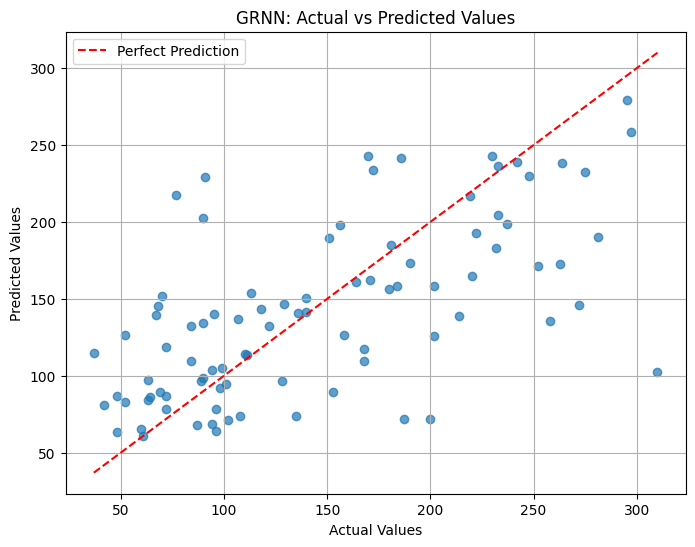

In [1]:
# Step 1: Import required libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Step 2: Load the Diabetes dataset
data = load_diabetes()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)

# Step 3: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# Step 4: Standardize the input features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Define the GRNN prediction function
def grnn_predict(X_train, y_train, X_test, sigma=0.5):

    predictions = []

    for sample in X_test:
        # Calculate squared Euclidean distances
        distances = np.sum(
            (X_train - sample) ** 2,
            axis=1
        )

        # Calculate Gaussian kernel weights
        weights = np.exp(
            -distances / (2 * sigma ** 2)
        )

        # Weighted average of target values
        prediction = np.sum(weights * y_train) / np.sum(weights)

        predictions.append(prediction)

    return np.array(predictions)

# Step 6: Make predictions using GRNN
# Sigma controls the smoothing level
sigma = 0.5

y_pred = grnn_predict(
    X_train_scaled,
    y_train,
    X_test_scaled,
    sigma
)

# Step 7: Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nGRNN Evaluation Results")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Step 8: Display actual and predicted values
print("\nActual vs Predicted Values:")
for i in range(10):
    print(
        f"Actual: {y_test[i]:.2f}, "
        f"Predicted: {y_pred[i]:.2f}"
    )

# Step 9: Plot actual vs predicted values
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

# Reference line for perfect predictions
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "r--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("GRNN: Actual vs Predicted Values")
plt.legend()
plt.grid(True)
plt.show()